#  案例实战：Phi-4 DPO 微调

In [1]:
import re
import json
import math
import torch
import datasets
import transformers
import os
import peft
from tqdm import tqdm
import pandas as pd
from transformers import AutoModelForCausalLM
from trl import DPOConfig, DPOTrainer
from peft import LoraConfig, TaskType
from importlib.metadata import version

from prompts import PROMPT # 提示词


In [2]:
print(f"torch: {version("torch")}")
print(f"peft: {version("peft")}")
print(f"transformers: {version("transformers")}")
print(f"trl: {version("trl")}")

torch: 2.7.0
peft: 0.17.1
transformers: 4.53.1
trl: 0.18.1


# 加载模型和tokenzier

In [3]:
model_path = "output/phi-4-sft/merged_phi4_sft/"

# 加载Phi4-mini-instruct阶段的模型
model = AutoModelForCausalLM.from_pretrained(model_path)
model_size = sum(t.numel() for t in model.parameters())
print(f"Model Size: {model_size/1000**2:.1f}M parameters")

# 加载自定义Tokenizer
tokenizer = transformers.AutoTokenizer.from_pretrained(model_path, use_fast=False)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model Size: 3836.0M parameters


In [4]:
messages = [
    {"role": "system", "content": "你是一个优秀的聊天机器人，总是给我正确的回应！"},
    {"role": "user", "content": '你好'},
    {"role": "assistant", "content": 'hello'},
]
new_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
print('-'*100)
print(new_prompt)

----------------------------------------------------------------------------------------------------
<|system|>你是一个优秀的聊天机器人，总是给我正确的回应！<|end|><|user|>你好<|end|><|assistant|>hello<|end|><|assistant|>


In [5]:
print(model)

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(200064, 3072, padding_idx=199999)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=5120, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLU()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_features=20006

# 处理数据

In [6]:
# 数据预处理函数
def process_dataset(dataset_path):
    examples = []
    output_text = {
        "prompt": [],
        "chosen": [],
        "rejected": []
    }
    raw_data = open(dataset_path, 'r').readlines()
    for line in tqdm(raw_data, total=len(raw_data), desc="Processint Data"):
        example = json.loads(line)
        prompt = f"<|system|>{PROMPT}<|end|><|user|>{example['prompt']}<|end|><|assistant|>"
        chosen = f"{example['chosen']}<|end|>"
        rejected = f"{example['rejected']}<|end|>"
        output_text["prompt"].append(prompt)
        output_text["chosen"].append(chosen)
        output_text["rejected"].append(rejected)

    dataset = datasets.Dataset.from_dict(output_text)
    dataset = dataset.shuffle()
    return dataset


In [7]:
train_dataset = process_dataset("./data/train_dpo_final_5k.json")
valid_dataset = process_dataset("./data/valid_dpo_final_500.json")
print("tokenize dataset info")
print(train_dataset)
print(valid_dataset)

Processint Data: 100%|██████████| 500/500 [00:00<00:00, 299764.44it/s]

tokenize dataset info
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 5000
})
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 500
})


# 训练参数

In [8]:
# 定义LoRA微调参数
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM, # 生成式的模型
    target_modules=["o_proj", "qkv_proj", "gate_up_proj", "down_proj"], # Attention + FFN
    inference_mode=False, # 训练模式
    r=32,                 # LoRA rank
    lora_alpha=16,        # LoRA alpha
    bias="none",          # 不添加bias
    lora_dropout=0.1,     # Dropout比例，防止过拟合
)

In [9]:
# 训练参数配置
training_args = DPOConfig(
    output_dir="output/dpo-phi4-adgen",
    per_device_train_batch_size=2,  # 每个GPU的训练batch数
    per_device_eval_batch_size=8,   # 评估的batch size
    gradient_accumulation_steps=8,  # 梯度累计总数
    overwrite_output_dir=True,      # 是否要覆盖输出文件
    logging_steps=10,               
    save_steps=500,
    eval_steps=50,
    eval_strategy="steps",
    learning_rate=2e-6,
    warmup_ratio=0.1,    # warmup 比例
    optim="adamw_torch",  # 优化器使用adamw
    lr_scheduler_type="cosine",  # 学习率衰减策略
    num_train_epochs=1,
    save_total_limit=1,
    dataset_num_proc=16,   #数据处理的workers
    label_names=["labels"],
    # loss_type=["sigmoid", "sft"],  # MPO loss, 新版本trl支持
    # loss_weights=[1.0, 0.1],  # loss 权重
    bf16=True
)

In [10]:
# 初始化Trainer
trainer = DPOTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    peft_config=lora_config
)

Extracting prompt in train dataset (num_proc=16):   0%|          | 0/5000 [00:00<?, ? examples/s]

Applying chat template to train dataset (num_proc=16):   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=16):   0%|          | 0/5000 [00:00<?, ? examples/s]

Extracting prompt in eval dataset (num_proc=16):   0%|          | 0/500 [00:00<?, ? examples/s]

Applying chat template to eval dataset (num_proc=16):   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset (num_proc=16):   0%|          | 0/500 [00:00<?, ? examples/s]

# 开始训练

In [11]:
trainer.train()

Step,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
50,0.544100,0.494679,-0.016496,-0.474471,0.994048,0.457974,-256.996857,-325.694458,0.007127,0.639630
100,0.154000,0.125013,-0.730626,-3.000846,0.998016,2.270220,-264.138153,-350.958221,-0.159994,0.474739
150,0.015400,0.014320,-2.203923,-7.190772,1.000000,4.986849,-278.871094,-392.857422,-0.367775,0.264245
200,0.006200,0.007164,-2.541143,-8.364981,1.000000,5.823838,-282.243317,-404.599548,-0.436183,0.194468
250,0.004300,0.005917,-2.634130,-8.691273,1.000000,6.057141,-283.173187,-407.862488,-0.457296,0.174388
300,0.003900,0.005808,-2.669457,-8.769287,1.000000,6.099831,-283.526459,-408.642639,-0.460741,0.170795


TrainOutput(global_step=312, training_loss=0.16065133810759738, metrics={'train_runtime': 1702.8441, 'train_samples_per_second': 2.936, 'train_steps_per_second': 0.183, 'total_flos': 0.0, 'train_loss': 0.16065133810759738, 'epoch': 0.9984})

# 可视化结果

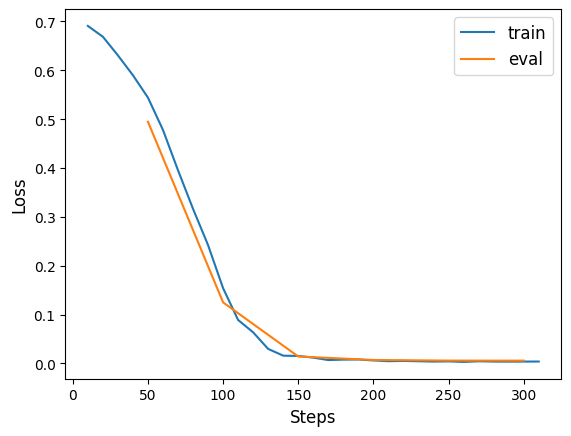

In [12]:
import matplotlib.pyplot as plt
history = trainer.state.log_history
train_steps = [item["step"] for item in history if "loss" in item]
train_loss = [item["loss"] for item in history if "loss" in item]
eval_steps = [item["step"] for item in history if "eval_loss" in item]
eval_loss = [item["eval_loss"] for item in history if "eval_loss" in item]

plt.plot(train_steps, train_loss, label="train")
plt.plot(eval_steps, eval_loss, label="eval")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=12)
plt.show()

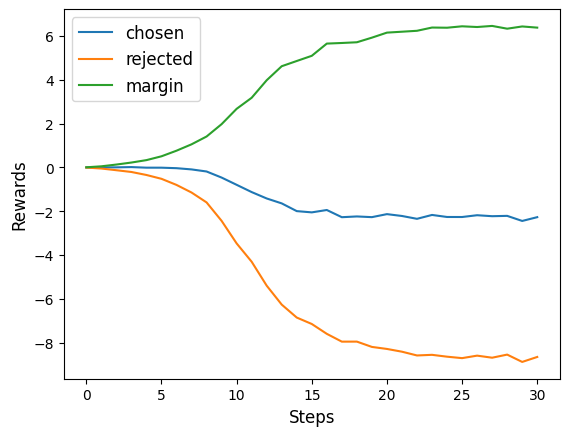

In [13]:
# reward曲线
chosen_reward = [item["rewards/chosen"] for item in history if "rewards/chosen" in item]
rejected_reward = [item["rewards/rejected"] for item in history if "rewards/rejected" in item]
margins = [item["rewards/margins"] for item in history if "rewards/margins" in item]

plt.plot(chosen_reward, label="chosen")
plt.plot(rejected_reward, label="rejected")
plt.plot(margins, label="margin")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Rewards", fontsize=12)
plt.legend(fontsize=12)
plt.show()

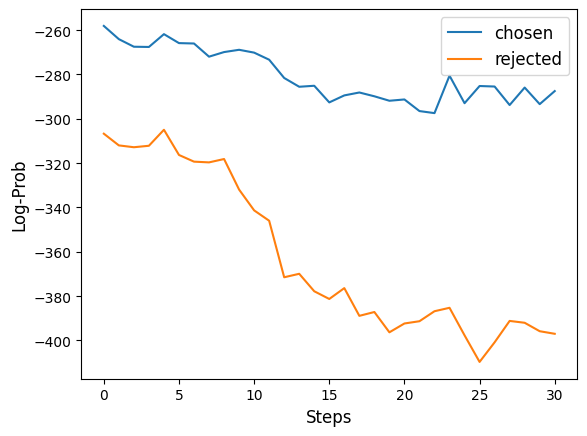

In [14]:
# logp曲线
logps_chosen = [item["logps/chosen"] for item in history if "logps/chosen" in item]
logps_rejected = [item["logps/rejected"] for item in history if "logps/rejected" in item]

plt.plot(logps_chosen, label="chosen")
plt.plot(logps_rejected, label="rejected")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Log-Prob", fontsize=12)
plt.legend(fontsize=12)
plt.show()

# 预测部分

In [16]:
def predict(messages, model, tokenizer):
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to("cuda")

    generated_ids = model.generate(
        model_inputs.input_ids,
        max_new_tokens=512,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]     
    return response

In [17]:
# 用测试集的随机5条，测试模型
test_dataset_path = "data/test_dpo_final.json"
test_df = pd.read_json(test_dataset_path, lines=True)

sample_test = test_df.sample(n=5)
for index, row in sample_test.iterrows():
    messages = [
        {"role": "system", "content": f"{PROMPT}"},
        {"role": "user", "content": f"{row['prompt']}"}
    ]
    response = predict(messages, model, tokenizer)
    messages.append({"role": "assistant", "content": f"{response}"})
    print(messages[1]['content'], "===>", messages[2]['content'])


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


类型#裙*版型#宽松*版型#显瘦*颜色#黑色*裙型#直筒裙*裙长#连衣裙*裙款式#腰带 ===> 这款黑色直筒连衣裙简直是日常穿搭的宝藏单品！宽松的版型藏肉又显瘦，完美修饰身材曲线，轻松遮住小肚腩和大腿赘肉，穿上瞬间拥有利落显瘦的效果～经典黑色百搭不挑人，不管是通勤上班、周末和闺蜜逛街还是约会出游，都能轻松hold住！直筒裙型利落大方，搭配可调节的腰带，轻松勾勒纤细腰线，让身材比例更显高挑；腰带的细节点缀增添了几分小心机，让整体造型更具层次感。穿上它，既舒适自在又时髦吸睛，谁穿谁好看，赶紧入手解锁你的百变穿搭吧！
类型#裙*风格#复古*风格#文艺*风格#简约*风格#清新*图案#碎花*图案#复古*图案#线条*裙型#大裙摆*裙下摆#垂坠*裙长#连衣裙*裙袖长#无袖*裙款式#收腰 ===> 这款复古文艺风的无袖连衣裙简直是春夏穿搭的宝藏单品！清新简约的风格与复古文艺的精致碰撞，碎花与复古线条交织出温柔又有格调的图案，走动间裙摆轻垂坠，每一步都带着灵动飘逸的氛围感～无袖设计透气又显瘦，收腰版型巧妙修饰腰线，轻松勾勒纤细腰腹，大裙摆的长度恰到好处，既能遮住小肚腩，又不会拖沓，日常出街、周末约会或是和闺蜜小聚都超合适！穿上它，仿佛把复古书页里的温柔与文艺气息穿在身上，清新又不失优雅，轻松打造出浪漫又时髦的造型，谁穿谁好看，赶紧入手解锁你的复古文艺春夏穿搭吧！
类型#上衣*风格#简约*风格#青春*风格#潮*风格#性感*图案#条纹*图案#撞色*衣样式#衬衫*衣领型#圆领*衣袖长#五分袖*衣款式#拼接 ===> 这件简约又潮酷的拼接圆领五分袖衬衫，绝对是青春少女的衣橱必备！经典的圆领设计温柔贴合颈部线条，轻松修饰脸型显脸小；五分袖的剪裁刚好露出纤细手腕，瞬间拉满少女感；拼接款式打破单调感，撞色条纹点缀其间，既保留了简约的利落感，又添了几分潮酷与性感的层次感。不管是搭配牛仔裤打造休闲日常look，还是配半身裙打造温柔甜美感，都能轻松hold住各种场合，穿上它你就是人群中最亮眼的青春少女，既有清爽的简约风，又有吸睛的潮酷感，谁能拒绝这样的百搭又好看的上衣呢？赶紧入手，让它成为你衣橱里的必备款！
类型#上衣*版型#宽松*版型#显瘦*颜色#白色*颜色#绿色*风格#简约*风格#休闲*衣样式#衬衫*衣款式#不规则 ===> 这款简约休闲风的白色衬衫简直是日常穿搭的宝藏单品！宽松的版型对各种身材都